In [ ]:
# Windows 10/11
!winget install Graphviz.Graphviz
!python -m pip install --config-settings="--global-option=build_ext" --config-settings="--global-option=-IC:\Program Files\Graphviz\include" --config-settings="--global-option=-LC:\Program Files\Graphviz\lib" pygraphviz

In [ ]:
# Ubuntu
!sudo apt-get install graphviz
!pip install pygraphviz

In [ ]:
# Mac
!brew install graphviz
!pip install pygraphviz

In [ ]:
!pip install networkx matplotlib

In [2]:
# Open node.log and extract the data from it
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

def parse_input(input_data):
    edges = []
    labels = {}
    
    lines = input_data.strip().split('\n')
    for line in lines:
        parts = line.split(' ')
        if parts[0].startswith('State'):
            state_id = int(parts[0].split('[')[1].split(']')[0])
            state_name = line.split('name(')[1].split(')')[0]
            labels[state_id] = state_name
        elif parts[0].startswith('Node'):
            node_id = int(parts[0].split('[')[1].split(']')[0])
            parent_id = int(parts[-1].split('(')[1].split(')')[0])
            edges.append((parent_id, node_id))

    return edges, labels

def create_graph(edges, labels):
    # Create a directed graph
    G = nx.DiGraph()

    # Add edges to the graph
    G.add_edges_from(edges)

    # Set the labels
    pos = graphviz_layout(G, prog='dot')
    nx.draw(G, pos, with_labels=True, labels={node: labels.get(node, node) for node in G.nodes()})
    plt.title("Graph Representation of States and Nodes")
    plt.show()

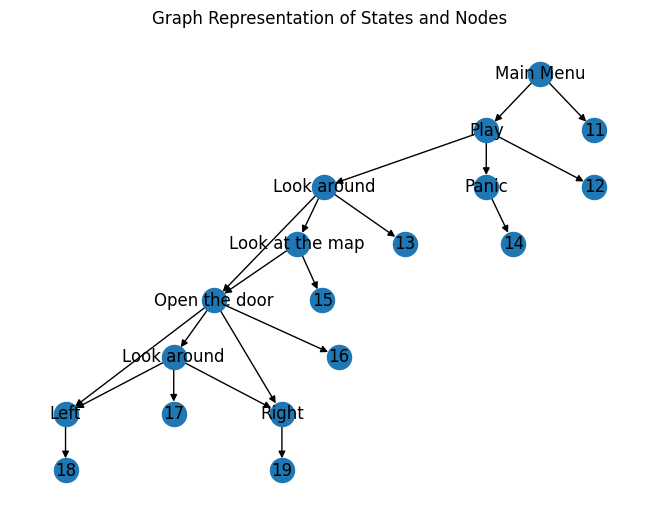

In [3]:
# open the file and parse the data
with open('debug.log', 'r') as file:
    input_data = file.read()
    edges, labels = parse_input(input_data)
    create_graph(edges, labels)